## Анализ результатов А/В-тестирования нового онбординга в SollmaFin 

SollmaFin — международное финтех-приложение для начинающих инвесторов на рынке Латинской Америки (Мексика, Бразилия, Колумбия, Аргентина).

**Проблема:** Исторический анализ показал, что пользователи часто выбирали высокорискованные активы без понимания последствий, теряли средства на старте и уходили из приложения (высокий отток после первого депозита).
**Решение:** Разработан обновленный онбординг с детальным обучением рискам.
**Риски фичи:** Усложнение воронки могло снизить конверсию в первый депозит и отпугнуть осторожных клиентов.

Для проверки влияния фичи на метрики был проведен A/B-тест.


### Дизайн Эксперимента

* **Период проведения:** С 2 по 15 июня 2025 года.
* **Сегмент:** Новые пользователи (Mobile & Web).
* **Группы:**  **Контроль (A):** Стандартный онбординг без обязательного обучения.
* **Тест (B):** Обновленный онбординг с фокусом на финансовую грамотность и риски.


* **Окно конверсии:** Активность пользователей анализировалась в течение 7 дней с момента регистрации.

#### Метрики эксперимента:

* **Ключевая (North Star):** ARPU (Средняя сумма всех депозитов на одного зарегистрированного пользователя).
* **Барьерная (Guardrail):** Конверсия ($CR$) из регистрации в первый депозит.
* **Вспомогательные:** * Конверсия из первого депозита во второй.
* ARPPU (Средний чек платящего пользователя).



### Бизнес-гипотезы

1. **Гипотеза роста:** Обучение повысит осознанность пользователей, что увеличит конверсию во второй депозит.
2. **Гипотеза риска:** Информирование о рисках может снизить $CR$ в первый депозит среди осторожных пользователей.
3. **Гипотеза удержания:** Пользователи, выбравшие high-risk активы после нового онбординга, будут чаще возвращаться за вторым депозитом, так как их ожидания были сформированы корректно.


### Этапы исследования

#### 1. Анализ исторических данных (Ретроспективный анализ)

* Оценка динамики привлечения пользователей и базовая сегментация по странам и платформам.
* Расчет конверсий и выявление узких мест в текущей воронке до момента совершения второго депозита.
* Анализ распределения сумм пополнений и структуры портфеля (low/medium/high risk).

#### 2. Оценка результатов A/B-теста

* Проверка корректности сплитования групп.
* Статистическая оценка изменений ключевой (ARPU) и барьерной ($CR$) метрик. Применение статистических тестов для долей и непрерывных величин.
* Сегментационный анализ результатов по странам, платформам и уровням риска выбранных активов.

#### 3. Анализ распределения депозитов (ARPPU)

* Исследование влияния онбординга на платящую аудиторию.
* Применение метода **Bootstrap** для детального анализа изменений в нижних (осторожные инвесторы) и верхних (крупные игроки / киты) перцентилях распределения сумм депозитов.

#### 4. Итоговые выводы и рекомендации

* Принятие решения о раскатке фичи на всю аудиторию.
* Формирование продуктовых инсайтов по оптимизации монетизации и улучшению UX.

Выполнил: Камалов Тимур
Дата: 01-07-2026

In [1]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

In [2]:
# Выгружаем датасет
event_df = pd.read_csv('https://code.s3.yandex.net/datasets/pa_sollmafin_hist.csv',parse_dates=['first_ts','first_dt','event_ts'])
display(event_df.head())
print(event_df.info())
print(event_df.shape)

,user_id,country_code,platform,first_ts,first_dt,event_ts,event_name,amount,asset,risk_level
0,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 19:55:51,install / open_web,NaN,NaN,NaN
1,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 19:55:59,introduction,NaN,NaN,NaN
2,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:46:06,registration,NaN,NaN,NaN
3,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:46:15,main_page,NaN,NaN,NaN
4,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:47:59,onboarding_complete,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238059 entries, 0 to 238058
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   user_id       238059 non-null  object        
 1   country_code  238059 non-null  object        
 2   platform      238059 non-null  object        
 3   first_ts      238059 non-null  datetime64[ns]
 4   first_dt      238059 non-null  datetime64[ns]
 5   event_ts      238059 non-null  datetime64[ns]
 6   event_name    238059 non-null  object        
 7   amount        33093 non-null   float64       
 8   asset         15392 non-null   object        
 9   risk_level    15392 non-null   object        
dtypes: datetime64[ns](3), float64(1), object(6)
memory usage: 18.2+ MB
None
(238059, 10)


In [3]:
# Выводим пропуски и дубликаты
print('Число пропусков по столбцам:')
print(event_df.isnull().sum())
print('Число явных дубликатов:')
print(event_df.duplicated().sum())

Число пропусков по столбцам:
user_id              0
country_code         0
platform             0
first_ts             0
first_dt             0
event_ts             0
event_name           0
amount          204966
asset           222667
risk_level      222667
dtype: int64
Число явных дубликатов:
0


In [4]:
# Выводим основые параметры и их разнообразие
print('Уникальные события:', event_df['event_name'].unique())
print('Страны:', event_df['country_code'].unique())
print('Платформы:', event_df['platform'].unique())
print('Уровни риска:', event_df['risk_level'].unique()[1:])
print('Уникальных пользователей:', event_df['user_id'].nunique())
print('Уникальных активов:', event_df['asset'].unique()[1:])

Уникальные события: ['install / open_web' 'introduction' 'registration' 'main_page'
 'onboarding_complete' 'first_deposit' 'asset_purchase' 'second_deposit']
Страны: ['BR' 'AR' 'CO' 'MX']
Платформы: ['mobile' 'web']
Уровни риска: ['medium' 'high' 'low']
Уникальных пользователей: 41032
Уникальных активов: ['stock' 'option' 'crypto']


In [5]:
# Какие события имеют amount и asset/risk_level
print(event_df[event_df['amount'].notna()]['event_name'].value_counts())
print(event_df[event_df['risk_level'].notna()]['event_name'].value_counts())

first_deposit     27685
second_deposit     5408
Name: event_name, dtype: int64
asset_purchase    15392
Name: event_name, dtype: int64


In [6]:
# Проверяем диапазона дат, наличие событий до first_ts и смотрим описание по суммам депозитов
print(f'Диапазон event_ts: {event_df["event_ts"].min()} — {event_df["event_ts"].max()}')

weird_events = event_df[event_df['event_ts'] < event_df['first_ts']]
print(f'Событий до first_ts: {len(weird_events)}')

deposits = event_df[event_df['amount'].notna()]['amount']
print(deposits.describe())

Диапазон event_ts: 2025-04-01 00:06:34 — 2025-06-09 20:24:42
Событий до first_ts: 0
count    33093.000000
mean       113.527967
std         34.472458
min         27.000000
25%         90.000000
50%        109.000000
75%        131.000000
max        524.000000
Name: amount, dtype: float64


В ходе первого этапа была проведена предобработка датасета, хранящего исторические данные о ключевых действиях новых пользователей, привлечённых в период с 1 апреля по 1 июня 2025 года включительно. В датасете собраны действия пользователей до оформления второго депозита.
- Датасет содержит 238059 строк и 10 столбцов;
- При считывании датасета столбцы с датой были приведены к типу `datetime64`;
- Явных дубликатов не обнаружено;
- Пропуски в amount, asset и risk_level связаны с тем, что не все записи отражают платящих пользователей, с внесенными депозитами и в таких строках допустимо использование `Nan`;
- Представлены уникальные события: `install / open_web`, `introduction`, `registration`, `main_page`, `onboarding_complete`, `first_deposit`, `asset_purchase`, `second_deposit`,уникальные страны: `BR`,`AR`,`CO`,`MX`, уникальные платформы: `mobile`,`web`, уровни риска: `medium`,`high`,`low`, уникальных пользователей: 41032, уникальные активы: `stock`,`option`,`crypto`.
- Диапазон событий представлен корректно, а именно с `01.04.2025` по `09.06.2025`;
- Событий, произошедших до первого взаимодействия пользователя, не обнаружено, данные корректны;
- Описательная статистика сумм одного депозита следующая: среднее **113.53**, медиана **109**, минимум **27**, максимум **524**. Стандартное отклонение **34.47** относительно среднего невысокое, слишком экстремальных выбросов, способных исказить среднее и std, в исторических данных нет.

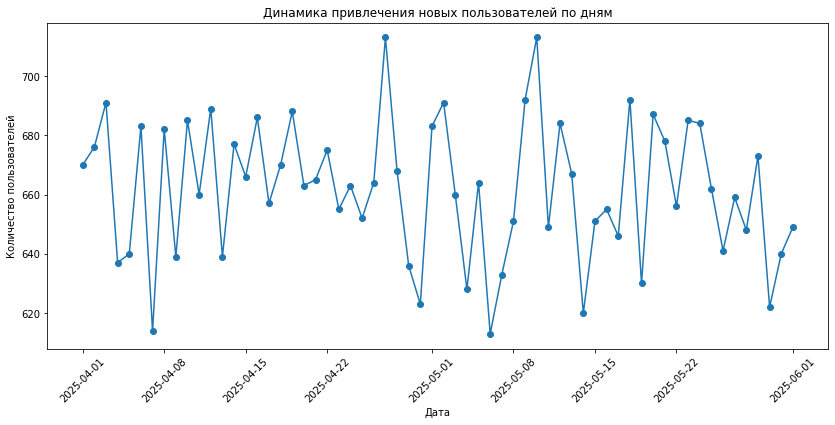

In [7]:
# Анализируем распределение новых пользователей
user_acquisition = event_df.groupby('first_dt')['user_id'].nunique().reset_index()
plt.figure(figsize=(14,6))
plt.plot(user_acquisition['first_dt'],user_acquisition['user_id'],marker='o')
plt.title('Динамика привлечения новых пользователей по дням')
plt.ylabel('Количество пользователей')
plt.xlabel('Дата')
plt.xticks(rotation=45)
plt.show()

Распределение привлечения новых пользователей на протяжении всего периода динамически скачет в пределах **620-700** без явного тренда.

In [8]:
# Считаем конверсии по пути пользователя
funnel_steps = ['install / open_web', 'introduction', 'registration', 'main_page', 'onboarding_complete','first_deposit','asset_purchase','second_deposit']

funnel_df_steps = event_df[event_df['event_name'].isin(funnel_steps)]

funnel_counts = funnel_df_steps.groupby('event_name')['user_id'].nunique().reindex(funnel_steps)

funnel_df = pd.DataFrame({
    'step': funnel_counts.index,
    'users': funnel_counts.values
})

funnel_df['conversion_from_first_%'] = (funnel_df['users'] / funnel_df['users'].loc[0] * 100).round(1)
funnel_df['conversion_from_previous_%'] = (funnel_df['users'] / funnel_df['users'].shift(1) * 100).round(1)

print(funnel_df)

                  step  users  conversion_from_first_%  \
0   install / open_web  41032                    100.0   
1         introduction  41032                    100.0   
2         registration  38133                     92.9   
3            main_page  35040                     85.4   
4  onboarding_complete  34337                     83.7   
5        first_deposit  27685                     67.5   
6       asset_purchase  15392                     37.5   
7       second_deposit   5408                     13.2   

   conversion_from_previous_%  
0                         NaN  
1                       100.0  
2                        92.9  
3                        91.9  
4                        98.0  
5                        80.6  
6                        55.6  
7                        35.1  


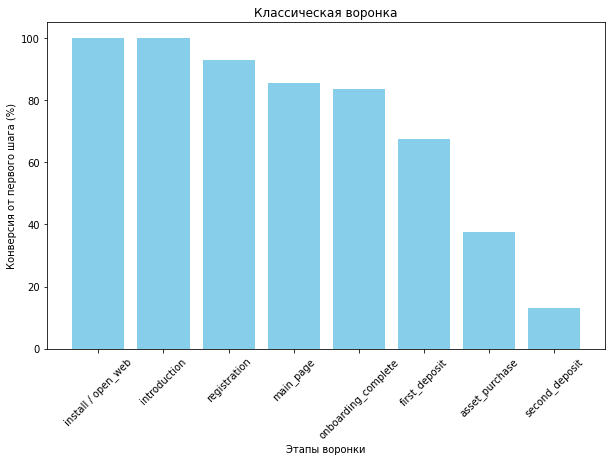

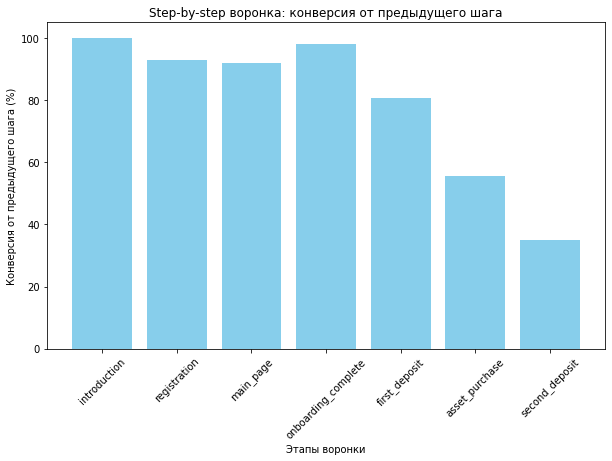

In [9]:
# Строим графики

plt.figure(figsize=(10, 6))
plt.bar(funnel_df['step'], funnel_df['conversion_from_first_%'], color='skyblue')
plt.title('Классическая воронка')
plt.ylabel('Конверсия от первого шага (%)')
plt.xlabel('Этапы воронки')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(funnel_df['step'][1:], funnel_df['conversion_from_previous_%'][1:], color='skyblue')
plt.title('Step-by-step воронка: конверсия от предыдущего шага')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.xlabel('Этапы воронки')
plt.xticks(rotation=45)
plt.show()

Вывод по воронкам:
- Воронка пользователя содержит **8** основных этапов: всё начинается с `install / open_web` — установки приложения или открытия веб-версии, далее этап `introduction` — введение в продукт, следом `registration` — регистрация, затем `main_page` — загрузка основной страницы, потом `onboarding_complete` — завершение онбординга, далее идут ключевые финансовые действия: `first_deposit` — первый депозит, `asset_purchase` — покупка актива и, наконец, `second_deposit`, что означает открытие второго депозита.
- Общая конверсия из установки во второй депозит составляет **13.2%**. Из **41032** пользователей до второго депозита доходят только **5408**.
- Наибольший процент пользователей теряется между этапами `asset_purchase` и `second_deposit`, конверсия составляет **35.1%**, то есть **64.9%** пользователей уходят между этими шагами. Также сильная просадка видна между `first_deposit` и `asset_purchase`, тут конверсия составляет **55.6%**, это значит, что после первого пополнения примерно половина пользователей не покупает активы. На остальных шагах конверсия держится в диапазоне **80–98%**. Такая динамика на финальных этапах подтверждает гипотезу команды о низкой финансовой грамотности пользователей, клиенты делают первый депозит, но не понимают, что делать дальше, или покупают рискованные активы и теряют деньги, после чего не возвращаются за вторым депозитом.

In [10]:
# Считаем конверсию по рискам

buyers = event_df[event_df['event_name'] == 'asset_purchase'][['user_id', 'risk_level']].drop_duplicates(subset=['user_id'])

second_deposit_users = event_df[event_df['event_name'] == 'second_deposit']['user_id'].unique()

buyers['made_second_deposit'] = buyers['user_id'].isin(second_deposit_users)

conv_by_risk = buyers.groupby('risk_level').agg(buyers=('user_id', 'nunique'),converted=('made_second_deposit', 'sum')
).reset_index()
conv_by_risk['conversion_%'] = (conv_by_risk['converted'] / conv_by_risk['buyers'] * 100).round(1)

print(conv_by_risk)

  risk_level  buyers  converted  conversion_%
0       high    7740       2040          26.4
1        low    2327       1080          46.4
2     medium    5325       2288          43.0


Анализ конверсии по уровню риска первого актива наглядно показал, что выбор слишком рискованных активов на старте негативно влияет на второй депозит пользователей. Для клиентов, купивших активы с низким риском, конверсия во второй депозит составляет **46.4%**, для среднего риска этот показатель составляет **43.0%**, тогда как для высокорискованных активов этот показатель равен всего **26.4%**. То есть пользователи с `low` и `medium` активами возвращаются за вторым депозитом почти в **1.8** раза чаще, чем пользователи с `high`. При этом высокорискованные активы остаются самыми популярными среди новых пользователей, их покупают **7740** пользователей против **2327** у low и **5325** у medium. Получается, что большинство новичков , не разобравшись, выбирают самые рискованные активы, на которых они в последствии чаще теряют деньги и уходят. Это подтверждает гипотезу команды о низкой финансовой грамотности пользователей и обосновывает идею с обновлением онбординга.

In [11]:
# Анализируем ключевую метрику

total_deposits = event_df[event_df['event_name'].isin(['first_deposit', 'second_deposit'])]['amount'].sum()

total_users = event_df['user_id'].nunique()

arpu = total_deposits / total_users

print(f'Общая сумма депозитов: {total_deposits}')
print(f'Всего пользователей: {total_users}')
print(f'Средняя сумма депозитов на пользователя: {arpu}')

Общая сумма депозитов: 3756981.0
Всего пользователей: 41032
Средняя сумма депозитов на пользователя: 91.5622197309417


Платящих пользователей: 27,685
Доля платящих: 67.5%
Средняя сумма на платящего (ARPPU): 135.70


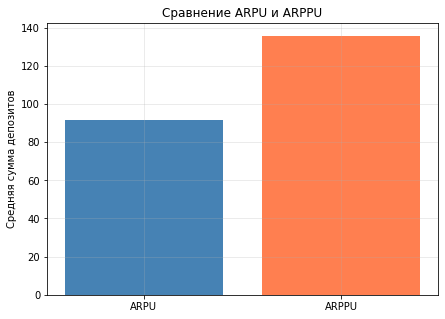

In [12]:
# Считаем метрику только для платящих и визуализируем

paying_users = event_df[event_df['event_name'].isin(['first_deposit', 'second_deposit'])]['user_id'].nunique()
arppu = total_deposits / paying_users

print(f'Платящих пользователей: {paying_users:,}')
print(f'Доля платящих: {paying_users / total_users * 100:.1f}%')
print(f'Средняя сумма на платящего (ARPPU): {arppu:,.2f}')

plt.figure(figsize=(7, 5))
plt.bar(['ARPU', 'ARPPU'], [arpu, arppu], color=['steelblue', 'coral'])
plt.title('Сравнение ARPU и ARPPU')
plt.ylabel('Средняя сумма депозитов')
plt.grid(alpha=0.3)
plt.show()

ARPU: 91.56
Стандартное отклонение суммы депозитов: 80.39
ARPPU: 135.70
Стандартное отклонение среди платящих: 59.90


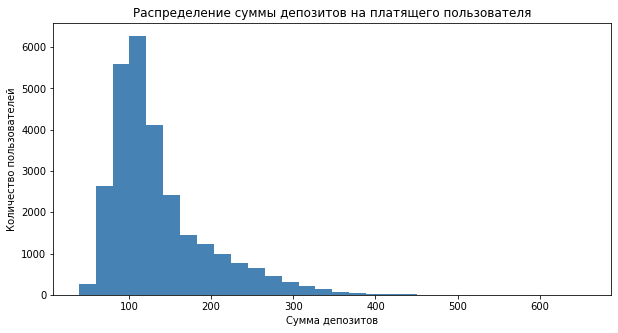

In [13]:
# Расчет std и гистограмма распределения
user_amounts_hist = event_df[event_df['event_name'].isin(['first_deposit', 'second_deposit'])].groupby('user_id')['amount'].sum()
user_amounts_all = user_amounts_hist.reindex(event_df['user_id'].unique(), fill_value=0)

print(f'ARPU: {user_amounts_all.mean():.2f}')
print(f'Стандартное отклонение суммы депозитов: {user_amounts_all.std():.2f}')
print(f'ARPPU: {user_amounts_hist.mean():.2f}')
print(f'Стандартное отклонение среди платящих: {user_amounts_hist.std():.2f}')

plt.figure(figsize=(10, 5))
plt.hist(user_amounts_hist, bins=30, color='steelblue')
plt.title('Распределение суммы депозитов на платящего пользователя')
plt.xlabel('Сумма депозитов')
plt.ylabel('Количество пользователей')
plt.show()

По историческим данным средняя сумма всех депозитов на одного пользователя составляет **91.56** — это и является базовым уровнем монетизации, от которого далее будем отталкиваться при анализе A/B-теста.
Платящих пользователей **67.5% (27685 из 41032)**, а средний депозит на одного платящего уже **135.70**. Разница между ARPU и ARPPU небольшая, то есть монетизация падает не столько из-за низкой конверсии в платящих, сколько из-за небольшого среднего размера депозита и редких повторных пополнений, также стоит помнить, что примерно половина из платящих впервые не покупают активы, что показала пошаговая конверсия.

Также стоит обратить внимание на стандартное отклонение. Для ARPU оно составляет **80.39**, что почти равно самому среднему и это говорит о большом разбросе среди пользователей, что означает, что часть пользователей не платит совсем,а часть, напротив, вкладывает крупные суммы. Среди платящих отклонение уже **59.90** при среднем **135.70**, тут разброс меньше, но всё равно довольно значительный. Гистограмма распределения депозитов скошена вправо, как видно по графику, основная масса пользователей вкладывает суммы в районе **100–150**, а длинный правый хвост из крупных депозитов доходит до 600 и делает дисперсию, среднее и стандартное отклонение больше. Это стоит учитывать при оценке A/B-эксперимента и оценивать дополнительные параметры, как перцентили и медиану.

In [14]:
# Загружаем данные
ab_df = pd.read_csv('https://code.s3.yandex.net/datasets/pa_sollmafin_abt.csv',parse_dates=['first_ts', 'first_dt', 'event_ts'])

display(ab_df.head())
print(ab_df.info())
print(ab_df.shape)

,user_id,country_code,platform,first_ts,first_dt,event_ts,event_name,ab_test,group,amount,asset,risk_level
0,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-07 19:55:51,install / open_web,onboarding_test,test,NaN,NaN,NaN
1,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-07 19:55:54,introduction,onboarding_test,test,NaN,NaN,NaN
2,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:18:09,registration,onboarding_test,test,NaN,NaN,NaN
3,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:18:13,main_page,onboarding_test,test,NaN,NaN,NaN
4,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:33:40,onboarding_complete,onboarding_test,test,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54805 entries, 0 to 54804
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       54805 non-null  object        
 1   country_code  54805 non-null  object        
 2   platform      54805 non-null  object        
 3   first_ts      54805 non-null  datetime64[ns]
 4   first_dt      54805 non-null  datetime64[ns]
 5   event_ts      54805 non-null  datetime64[ns]
 6   event_name    54805 non-null  object        
 7   ab_test       54805 non-null  object        
 8   group         54805 non-null  object        
 9   amount        7843 non-null   float64       
 10  asset         3750 non-null   object        
 11  risk_level    3750 non-null   object        
dtypes: datetime64[ns](3), float64(1), object(8)
memory usage: 5.0+ MB
None
(54805, 12)


In [15]:
# Пропуски и дубликаты
print('Число пропусков по столбцам:')
print(ab_df.isnull().sum())
print('Число явных дубликатов:')
print(ab_df.duplicated().sum())

Число пропусков по столбцам:
user_id             0
country_code        0
platform            0
first_ts            0
first_dt            0
event_ts            0
event_name          0
ab_test             0
group               0
amount          46962
asset           51055
risk_level      51055
dtype: int64
Число явных дубликатов:
0


In [16]:
# Изучаем уникальные значения
print('Уникальные события:', ab_df['event_name'].unique())
print('Страны:', ab_df['country_code'].unique())
print('Платформы:', ab_df['platform'].unique())
print('Уровни риска:', ab_df['risk_level'].dropna().unique())
print('Эксперимент:', ab_df['ab_test'].unique())
print('Группы:', ab_df['group'].unique())
print('Уникальных пользователей:', ab_df['user_id'].nunique())

Уникальные события: ['install / open_web' 'introduction' 'registration' 'main_page'
 'onboarding_complete' 'first_deposit' 'asset_purchase' 'second_deposit']
Страны: ['BR' 'MX' 'CO' 'AR']
Платформы: ['mobile' 'web']
Уровни риска: ['high' 'low' 'medium']
Эксперимент: ['onboarding_test']
Группы: ['test' 'control']
Уникальных пользователей: 9415


In [17]:
# Проверяем период данных
print('Период данных:', ab_df['event_ts'].min(), '—', ab_df['event_ts'].max())
print('Период регистраций:', ab_df['first_dt'].min().date(), '—', ab_df['first_dt'].max().date())

Период данных: 2025-06-02 00:27:50 — 2025-06-22 13:37:05
Период регистраций: 2025-06-02 — 2025-06-15


В ходе третьего этапа была проведена предобработка датасета, хранящего данные A/B-теста, в нем хранятся все действия новых пользователей, которые зарегистрировались со 2 по 15 июня 2025 года включительно. Данные собраны в рамках проверки гипотезы о влиянии нового онбординга на поведение и активность пользователей.

- Датасет содержит **54805** строк и **12** столбцов;
- При считывании датасета столбцы с датой были приведены к типу datetime64;
- Явных дубликатов не обнаружено;
- Пропуски в `amount`, `asset` и `risk_level` связаны с тем, что не все записи отражают платящих пользователей и тех, кто покупал активы, в таких строках допустимо использование Nan;
- Представлены уникальные события: `install / open_web`, `introduction`, `registration`, `main_page`, `onboarding_complete`, `first_deposit`, `asset_purchase`, `second_deposit`, уникальные страны: `BR, MX, CO, AR`, уникальные платформы: `mobile, web`, уровни риска: `high, low, medium`, уникальных пользователей: **9415**;
- A/B-тест в датасете один, это наш `onboarding_test`, пользователи распределены на две группы: `test` и `control`;

     group  users  share_%
0  control   4847     51.5
1     test   4568     48.5


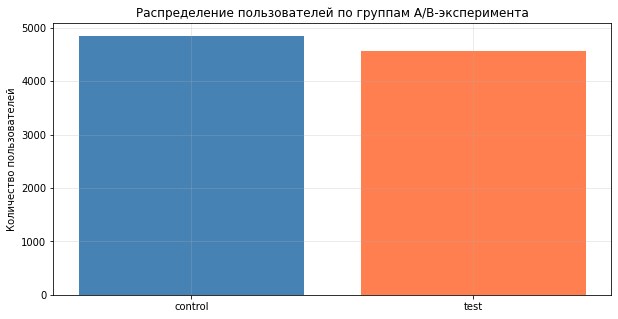

In [18]:
# Считаем количество уникальных пользователей в каждой группе и визуализируем
group_users = ab_df.groupby('group')['user_id'].nunique().reset_index()
group_users.columns = ['group', 'users']
group_users['share_%'] = (group_users['users'] / group_users['users'].sum() * 100).round(1)

print(group_users)

plt.figure(figsize=(10, 5))
plt.bar(group_users['group'], group_users['users'], color=['steelblue', 'coral'])
plt.title('Распределение пользователей по группам A/B-эксперимента')
plt.ylabel('Количество пользователей')
plt.grid(alpha=0.3)
plt.show()

In [19]:
# Проверяем также распределение по странам и платформам
country_dist = ab_df.groupby(['group', 'country_code'])['user_id'].nunique().unstack()
print('Распределение по странам:')
print(country_dist)
print()
platform_dist = ab_df.groupby(['group', 'platform'])['user_id'].nunique().unstack()
print('Распределение по платформам:')
print(platform_dist)

Распределение по странам:
country_code   AR    BR    CO    MX
group                              
control       756  1543  1247  1301
test          725  1448  1199  1196

Распределение по платформам:
platform  mobile   web
group                 
control     3385  1462
test        3246  1322


In [20]:
# Проверка на наличие клиентов в нескольких группах
users_in_both = ab_df.groupby('user_id')['group'].nunique()
users_in_both = (users_in_both > 1).sum()
print(f'Пользователей в обеих группах одновременно: {users_in_both}')

Пользователей в обеих группах одновременно: 0


Проверка распределения пользователей по группам A/B-эксперимента показала, что разделение по группам корректно:

- Общее распределение по группам получилось следующее: `control` — **4847 (51.5%)**, `test` — **4568 (48.5%)**. Небольшое отклонение от 50/50 находится в пределах нормы.
- Распределение по странам сбалансировано — расхождение долей групп для каждой страны в пределах 5%.
- Распределение по платформам также сбалансировано,`mobile около 70%, web около 30%` в обеих группах.

Также была выполнена проверка на наличие клиентов, находящихся в нескольких группах одновременно, их не обнаружено, следовательно гомогенность выборки соблюдена и разделение на группы можно считать полностью корректным.

После этого можно переходить к сравнению воронок событий.

In [21]:
# Сравниваем воронки для групп

funnel_steps = ['install / open_web', 'introduction', 'registration', 'main_page',
                'onboarding_complete', 'first_deposit', 'asset_purchase', 'second_deposit']

control_df = ab_df[ab_df['group'] == 'control']
test_df = ab_df[ab_df['group'] == 'test']

counts_control = control_df[control_df['event_name'].isin(funnel_steps)]
counts_control_agg = counts_control.groupby('event_name')['user_id'].nunique().reindex(funnel_steps)
control_first = (counts_control_agg / counts_control_agg.iloc[0] * 100).round(1)
control_prev = (counts_control_agg / counts_control_agg.shift(1) * 100).round(1)

counts_test = test_df[test_df['event_name'].isin(funnel_steps)]
counts_test_agg = counts_test.groupby('event_name')['user_id'].nunique().reindex(funnel_steps)
test_first = (counts_test_agg / counts_test_agg.iloc[0] * 100).round(1)
test_prev = (counts_test_agg / counts_test_agg.shift(1) * 100).round(1)

funnel_compare = pd.DataFrame({
    'step': funnel_steps,
    'control_users': counts_control_agg.values,
    'test_users': counts_test_agg.values,
    'control_from_first_%': control_first.values,
    'test_from_first_%': test_first.values,
    'control_from_previous_%': control_prev.values,
    'test_from_previous_%': test_prev.values
})

print(funnel_compare)

                  step  control_users  test_users  control_from_first_%  \
0   install / open_web           4847        4568                 100.0   
1         introduction           4847        4568                 100.0   
2         registration           4512        4265                  93.1   
3            main_page           4161        3919                  85.8   
4  onboarding_complete           4063        3462                  83.8   
5        first_deposit           3228        2987                  66.6   
6       asset_purchase           1773        1977                  36.6   
7       second_deposit            654         974                  13.5   

   test_from_first_%  control_from_previous_%  test_from_previous_%  
0              100.0                      NaN                   NaN  
1              100.0                    100.0                 100.0  
2               93.4                     93.1                  93.4  
3               85.8                     92.

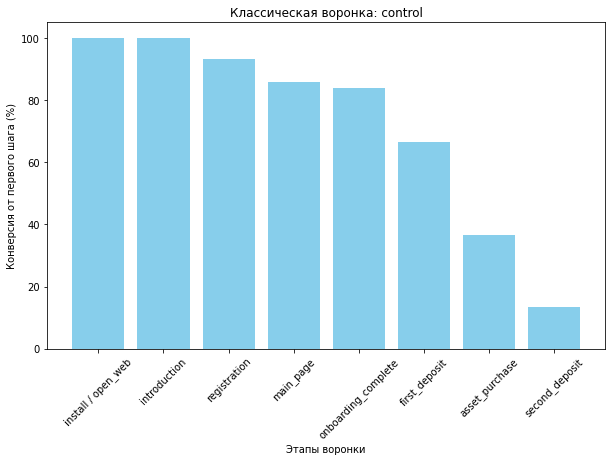

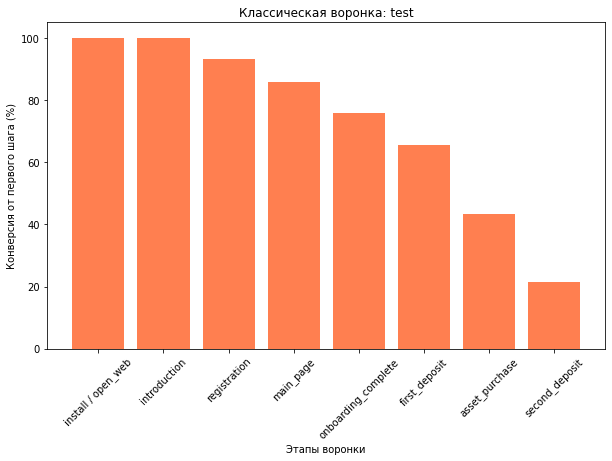

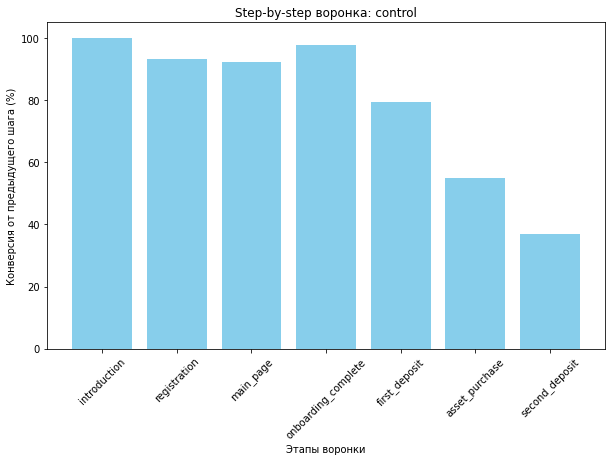

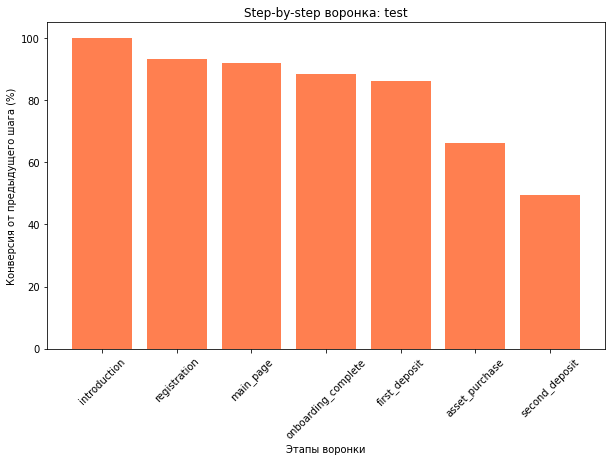

In [22]:
# Строим воронки
plt.figure(figsize=(10, 6))
plt.bar(funnel_steps, control_first.values, color='skyblue')
plt.title('Классическая воронка: control')
plt.ylabel('Конверсия от первого шага (%)')
plt.xlabel('Этапы воронки')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(funnel_steps, test_first.values, color='coral')
plt.title('Классическая воронка: test')
plt.ylabel('Конверсия от первого шага (%)')
plt.xlabel('Этапы воронки')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(funnel_steps[1:], control_prev.values[1:], color='skyblue')
plt.title('Step-by-step воронка: control')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.xlabel('Этапы воронки')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(funnel_steps[1:], test_prev.values[1:], color='coral')
plt.title('Step-by-step воронка: test')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.xlabel('Этапы воронки')
plt.xticks(rotation=45)
plt.show()

Вывод по воронкам:

- На первых шагах, таких как `introduction, registration, main_page` различий между группами почти нет, пользователи ведут себя практически одинаково.
- На этапе `onboarding_complete` тестовая группа теряет часть пользователей, конверсия от предыдущего шага составила **88.3%** против **97.6%** у контрольной. Это объясняется усложнением онбординга в пользу обучения пользователей грамотности ведения финансовых активов, поэтому теряем около 9 п.п.
- Зато дальше тестовая группа уже опережает контрольную, а именно: на переходе в `first_deposit` конверсия **86.3%** против **79.4%**, на покупке актива — **66.2%** против **54.9%**, а на втором депозите целых **49.3%** против **36.9%**.
- Общая конверсия из установки во второй депозит в тестовой группе составила **21.3%** против **13.5%** у контрольной, то есть выросла почти в **1.6 раз**. Это говорит о том, что новый онбординг действительно работает и помогает сохранить часть аудитории.
- Опасение команды, что новый онбординг отпугнёт пользователей от первого депозита в итоге не подтвердилось, что является отличным результатом, по факту конверсия в первый депозит в тесте даже немного выше.

In [23]:
# Смотрим влияние фичи для конверсии во второй депозит

buyers = (ab_df[ab_df['event_name'] == 'asset_purchase'].sort_values('event_ts').drop_duplicates(subset='user_id', keep='first')[['user_id', 'group', 'risk_level']])

second_deposit_users = ab_df[ab_df['event_name'] == 'second_deposit']['user_id'].unique()

buyers['made_second_deposit'] = buyers['user_id'].isin(second_deposit_users)

conv_by_risk = buyers.groupby(['group', 'risk_level']).agg(
    buyers=('user_id', 'nunique'),
    converted=('made_second_deposit', 'sum')
).reset_index()
conv_by_risk['conversion_%'] = (conv_by_risk['converted'] / conv_by_risk['buyers'] * 100).round(1)

print(conv_by_risk)

     group risk_level  buyers  converted  conversion_%
0  control       high     893        247          27.7
1  control        low     285        142          49.8
2  control     medium     595        265          44.5
3     test       high     737        339          46.0
4     test        low     496        285          57.5
5     test     medium     744        350          47.0


Сформулируем гипотезы для проверки статистической значимости по уровням риска:
- Гипотезы для теста конверсии по риску low:
    - H0: конверсия во второй депозит в тестовой и контрольной группах одинакова
    - H1: конверсия во второй депозит в группах различается
- Гипотезы для теста конверсии по риску medium:
    - H0: конверсия во второй депозит в тестовой и контрольной группах одинакова
    - H1: конверсия во второй депозит в группах различается
- Гипотезы для теста конверсии по риску high:
    - H0: конверсия во второй депозит в тестовой и контрольной группах одинакова
    - H1: конверсия во второй депозит в группах различается

In [24]:
# Проверяем статистическую значимость для каждого уровня риска через z-тест пропорций

for risk in ['low', 'medium', 'high']:
    control = conv_by_risk[(conv_by_risk['group'] == 'control') & (conv_by_risk['risk_level'] == risk)]
    test = conv_by_risk[(conv_by_risk['group'] == 'test') & (conv_by_risk['risk_level'] == risk)]
    
    successes = [test['converted'].values[0], control['converted'].values[0]]
    samples = [test['buyers'].values[0], control['buyers'].values[0]]
    
    z_stat, p_value = proportions_ztest(successes, samples)
    print(f'Уровень риска {risk}: p-value = {p_value:.3f}')

Уровень риска low: p-value = 0.039
Уровень риска medium: p-value = 0.361
Уровень риска high: p-value = 0.000


Анализ показал, что новый онбординг по-разному влияет на конверсию во второй депозит в зависимости от уровня риска купленного актива:

- Для высокорискованных активов конверсия выросла с **27.7% до 46.0%**, получается прирост в **18.3** п.п., при этом p-value = **0.000** — это самый сильный эффект, рост почти в 1.7 раз.
- Для низкорискованных активов конверсия выросла **с 49.8% до 57.5%** с приростом в **7.7** п.п., при этом p-value = **0.039**, также хороший рост.
- Для среднерискованных активов разница статистически незначима, получился рост **с 44.5% до 47.0%** с p-value = **0.361**.

Это подтверждает дополнительную гипотезу команды, о том, что после нового онбординга пользователи с высокорискованными активами действительно стали чаще возвращаться за вторым депозитом. Раньше они покупали такие активы вслепую и уходили с проекта после потерь, теперь же принимают более взвешенные решения по покупке активов с таким риском и впоследствии продолжают использовать сервис.



In [25]:
# Анализируем метрики выбранные для А/В-эксперимента
control_df = ab_df[ab_df['group'] == 'control']
test_df = ab_df[ab_df['group'] == 'test']

control_users = control_df['user_id'].nunique()
control_reg = control_df[control_df['event_name'] == 'registration']['user_id'].nunique()
control_first = control_df[control_df['event_name'] == 'first_deposit']['user_id'].nunique()
control_second = control_df[control_df['event_name'] == 'second_deposit']['user_id'].nunique()
control_amount = control_df[control_df['event_name'].isin(['first_deposit', 'second_deposit'])]['amount'].sum()

test_users = test_df['user_id'].nunique()
test_reg = test_df[test_df['event_name'] == 'registration']['user_id'].nunique()
test_first = test_df[test_df['event_name'] == 'first_deposit']['user_id'].nunique()
test_second = test_df[test_df['event_name'] == 'second_deposit']['user_id'].nunique()
test_amount = test_df[test_df['event_name'].isin(['first_deposit', 'second_deposit'])]['amount'].sum()

metrics = pd.DataFrame({
    'metric': ['ARPU', 'convertion_reg_fdep_%', 'convertion_fdep_secdep_%', 'ARPPU'],
    'control': [
        control_amount / control_users,
        control_first / control_reg * 100,
        control_second / control_first * 100,
        control_amount / control_first
    ],
    'test': [
        test_amount / test_users,
        test_first / test_reg * 100,
        test_second / test_first * 100,
        test_amount / test_first
    ]
})
metrics['absolute_diff'] = (metrics['test'] - metrics['control']).round(2)
metrics['relative_diff_%'] = ((metrics['test'] - metrics['control']) / metrics['control'] * 100).round(2)
metrics = metrics.round(2)
print(metrics)

                     metric  control    test  absolute_diff  relative_diff_%
0                      ARPU    90.24   92.46           2.22             2.46
1     convertion_reg_fdep_%    71.54   70.04          -1.51            -2.11
2  convertion_fdep_secdep_%    20.26   32.61          12.35            60.95
3                     ARPPU   135.50  141.40           5.90             4.35


Формулируем гипотезы для анализа метрик A/B-эксперимента:
- Гипотезы для ARPU:
    - H0: средняя сумма депозитов на пользователя в тестовой и контрольной группах одинакова
    - H1: средние отличаются
- Гипотезы для барьерной метрики:
    - H0: конверсия из регистрации в первый депозит одинакова
    - H1: конверсии отличаются
- Гипотезы для вспомогательной метрики 1:
    - H0: конверсия из первого во второй депозит одинакова
    - H1: конверсии отличаются

- Гипотезы для ARPPU:
    - H0: средняя сумма депозитов на платящего пользователя одинакова
    - H1: средние отличаются

In [26]:
# Проверяем статистическую значимость

control_amounts = control_df[control_df['event_name'].isin(['first_deposit', 'second_deposit'])].groupby('user_id')['amount'].sum()
test_amounts = test_df[test_df['event_name'].isin(['first_deposit', 'second_deposit'])].groupby('user_id')['amount'].sum()

control_arpu = control_amounts.reindex(control_df['user_id'].unique(), fill_value=0)
test_arpu = test_amounts.reindex(test_df['user_id'].unique(), fill_value=0)

p_arpu = ttest_ind(test_arpu, control_arpu).pvalue
p_barrier = proportions_ztest([test_first, control_first], [test_reg, control_reg])[1]
p_aux1 = proportions_ztest([test_second, control_second], [test_first, control_first])[1]
p_arppu = ttest_ind(test_amounts, control_amounts).pvalue

print(f'ARPU: p-value = {p_arpu:.4f}')
print(f'convertion_reg_fdep: p-value = {p_barrier:.4f}')
print(f'convertion_fdep_secdep: p-value = {p_aux1:.4f}')
print(f'ARPPU: p-value = {p_arppu:.4f}')

ARPU: p-value = 0.3313
convertion_reg_fdep: p-value = 0.1205
convertion_fdep_secdep: p-value = 0.0000
ARPPU: p-value = 0.0347


In [27]:
# Смотрим p-value по дням

ab_df['day_active'] = ab_df['event_ts'].dt.date

ab_filtered = ab_df[
    (ab_df['day_active'] >= pd.Timestamp('2025-06-02').date()) &
    (ab_df['day_active'] <= pd.Timestamp('2025-06-22').date())
]

records = []

for current_date in sorted(ab_filtered['day_active'].unique()):
    data_to_date = ab_filtered[ab_filtered['day_active'] <= current_date]

    deposits = data_to_date[data_to_date['event_name'].isin(['first_deposit', 'second_deposit'])]
    user_sums = deposits.groupby(['user_id', 'group'])['amount'].sum().reset_index()
    all_users = data_to_date[['user_id', 'group']].drop_duplicates()
    user_arpu = all_users.merge(user_sums, on=['user_id', 'group'], how='left').fillna(0)
    arpu_by_group = user_arpu.groupby('group')['amount'].mean().reset_index()
    control_vals = user_arpu[user_arpu['group'] == 'control']['amount']
    test_vals = user_arpu[user_arpu['group'] == 'test']['amount']
    p_value = ttest_ind(test_vals, control_vals).pvalue
    
    records.append({
        'date': current_date,
        'control_arpu': arpu_by_group[arpu_by_group['group'] == 'control']['amount'].values[0],
        'test_arpu': arpu_by_group[arpu_by_group['group'] == 'test']['amount'].values[0],
        'p_value': p_value
    })

arpu_df = pd.DataFrame(records)
print(arpu_df)

          date  control_arpu  test_arpu   p_value
0   2025-06-02      1.296703   0.175000  0.068485
1   2025-06-03     21.750355  15.532847  0.015544
2   2025-06-04     38.614068  32.718254  0.036423
3   2025-06-05     46.706007  41.373045  0.044654
4   2025-06-06     55.170718  48.353993  0.009878
5   2025-06-07     59.276360  55.790534  0.188542
6   2025-06-08     62.613534  61.759275  0.743899
7   2025-06-09     66.022151  64.272418  0.484634
8   2025-06-10     69.529829  66.494977  0.210852
9   2025-06-11     70.750578  70.113339  0.788452
10  2025-06-12     72.004483  72.567762  0.807813
11  2025-06-13     73.926588  75.103211  0.604941
12  2025-06-14     75.040231  76.116350  0.622429
13  2025-06-15     75.938519  76.976357  0.621321
14  2025-06-16     82.891479  83.958844  0.620166
15  2025-06-17     87.404374  87.775613  0.864628
16  2025-06-18     88.549206  90.691331  0.341102
17  2025-06-19     89.253353  91.785464  0.263951
18  2025-06-20     89.720858  92.241681  0.268229


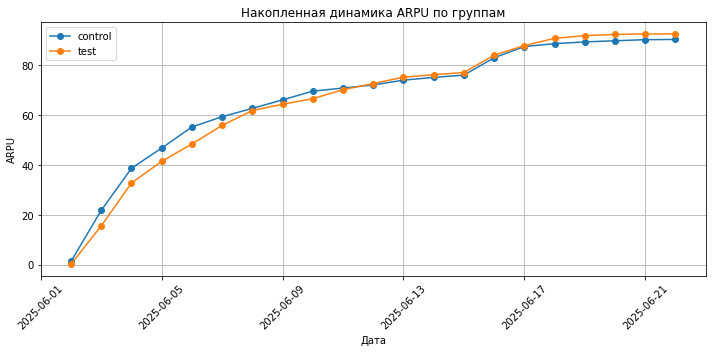

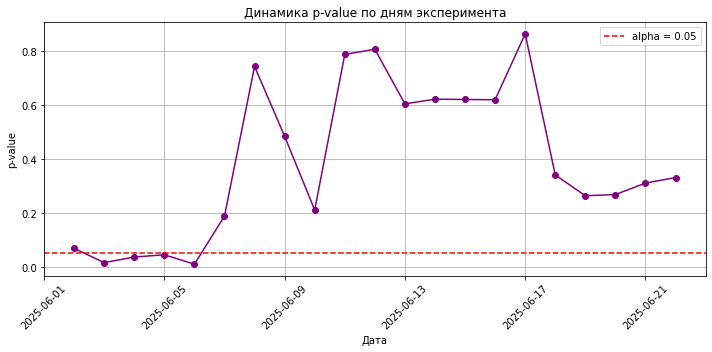

In [28]:
# Визуализируем

plt.figure(figsize=(10, 5))
plt.plot(arpu_df['date'], arpu_df['control_arpu'], marker='o', label='control')
plt.plot(arpu_df['date'], arpu_df['test_arpu'], marker='o', label='test')
plt.title('Накопленная динамика ARPU по группам')
plt.xlabel('Дата')
plt.ylabel('ARPU')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(arpu_df['date'], arpu_df['p_value'], marker='o', color='purple')
plt.axhline(y=0.05, linestyle='--', color='red', label='alpha = 0.05')
plt.title('Динамика p-value по дням эксперимента')
plt.xlabel('Дата')
plt.ylabel('p-value')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

По итогам эксперимента сравнение метрик показало:

- Ключевая метрика `ARPU` выросла с **90.24 до 92.46**, относительная разница получилась +2.46%, но p-value = 0.331, что означает, что рост статистически незначим.
- Барьерная метрика `конверсия в первый депозит` просела с **71.54% до 70.04% относительно: −2.11%**, но и p-value = 0.121, что говорит о том, что снижение также незначимо. Опасение команды о том, что новый онбординг отпугнёт пользователей, не подтвердилось.
- Вспомогательная метрика 1 `конверсия из первого депозита во второй` выросла с **20.26% до 32.61%**, рост составил 61%, p-value = 0.000, это самый сильный и статистически значимый эффект тестирования.
- Вспомогательная метрика 2 `ARPPU` выросла с **135.50 до 141.40 относительный рост на 4.35%)**, p-value при этом = 0.035, следовательно рост значимый и его можно подтвердить.

Отдельно по ARPU:

- Накопленная динамика ARPU показывает, что в первые дни эксперимента тестовая группа отставала, но к концу периода обогнала контрольную. Разрыв совсем небольшой, что и объясняет такой высокий p-value по ключевой метрике.
- Динамика p-value выглядит следующим образом: в первые дни эксперимента p-value было ниже 0.05, но это было ложноположительным сигналом из-за недостаточности данных, после их накопления значение стабилизировалось в районе 0.3. Это говорит о том, что останавливать тест при первом положительном эффекте ошибочно.

Получается итоговый вывод по A/B тесту:

Новый онбординг значимо повысил конверсию из первого депозита во второй и средний депозит на платящего пользователя, при этом не оказал значимого негативного влияния на первый депозит. Это говорит о том, что команде удалось решить проблему оттока после первой покупки, но ARPU сохраняется на прежнем уровне, а значит прослеживается новая точка роста, в стимулировании пользователей к более крупным депозитам. Это можно проверить в следующих тестах с введением каких-либо новшеств для платящих пользователей.

In [29]:
# Считаем ДИ через бутстрап-тест

np.random.seed(341)

control_amounts = ab_df[(ab_df['group'] == 'control') & 
                        (ab_df['event_name'].isin(['first_deposit', 'second_deposit']))].groupby('user_id')['amount'].sum().values

test_amounts = ab_df[(ab_df['group'] == 'test') & 
                     (ab_df['event_name'].isin(['first_deposit', 'second_deposit']))].groupby('user_id')['amount'].sum().values

n_iterations = 1000
boot_diffs_25 = []
boot_diffs_50 = []
boot_diffs_75 = []

for i in range(n_iterations):
    boot_control = np.random.choice(control_amounts, size=len(control_amounts), replace=True)
    boot_test = np.random.choice(test_amounts, size=len(test_amounts), replace=True)
    
    boot_diffs_25.append(np.percentile(boot_test, 25) - np.percentile(boot_control, 25))
    boot_diffs_50.append(np.percentile(boot_test, 50) - np.percentile(boot_control, 50))
    boot_diffs_75.append(np.percentile(boot_test, 75) - np.percentile(boot_control, 75))

boot_diffs_25 = np.array(boot_diffs_25)
boot_diffs_50 = np.array(boot_diffs_50)
boot_diffs_75 = np.array(boot_diffs_75)

ci_25 = np.percentile(boot_diffs_25, [2.5, 97.5])
ci_50 = np.percentile(boot_diffs_50, [2.5, 97.5])
ci_75 = np.percentile(boot_diffs_75, [2.5, 97.5])

print(f"25-й перцентиль control: {np.percentile(control_amounts, 25):.2f} | test: {np.percentile(test_amounts, 25):.2f}")
print(f"95%-й доверительный интервал разности 25-х перцентилей: [{ci_25[0]:.2f}, {ci_25[1]:.2f}]")
print()
print(f"50-й перцентиль control: {np.percentile(control_amounts, 50):.2f} | test: {np.percentile(test_amounts, 50):.2f}")
print(f"95%-й доверительный интервал разности 50-х перцентилей: [{ci_50[0]:.2f}, {ci_50[1]:.2f}]")
print()
print(f"75-й перцентиль control: {np.percentile(control_amounts, 75):.2f} | test: {np.percentile(test_amounts, 75):.2f}")
print(f"95%-й доверительный интервал разности 75-х перцентилей: [{ci_75[0]:.2f}, {ci_75[1]:.2f}]")

25-й перцентиль control: 95.00 | test: 48.00
95%-й доверительный интервал разности 25-х перцентилей: [-50.00, -44.00]

50-й перцентиль control: 118.00 | test: 94.00
95%-й доверительный интервал разности 50-х перцентилей: [-27.00, -19.00]

75-й перцентиль control: 159.00 | test: 179.50
95%-й доверительный интервал разности 75-х перцентилей: [11.00, 30.00]


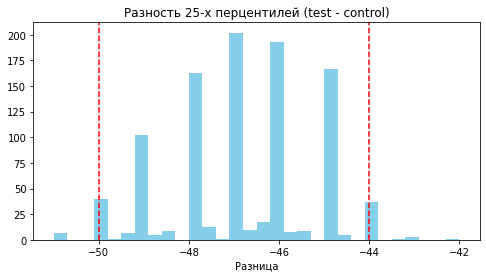

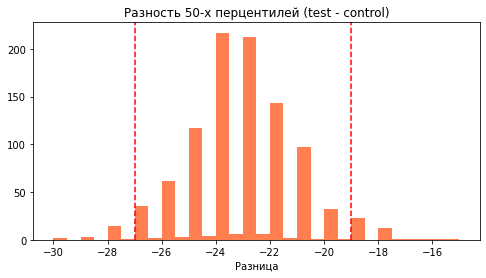

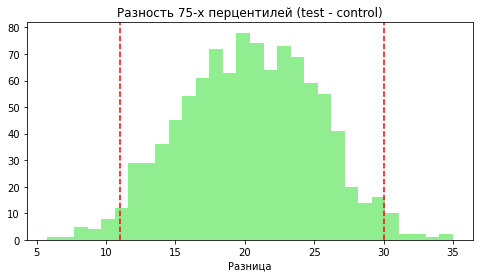

In [30]:
# Визуализируем

plt.figure(figsize=(8, 4))
plt.hist(boot_diffs_25, bins=30, color='skyblue')
plt.axvline(ci_25[0], linestyle='--', color='red')
plt.axvline(ci_25[1], linestyle='--', color='red')
plt.title('Разность 25-х перцентилей (test - control)')
plt.xlabel('Разница')
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(boot_diffs_50, bins=30, color='coral')
plt.axvline(ci_50[0], linestyle='--', color='red')
plt.axvline(ci_50[1], linestyle='--', color='red')
plt.title('Разность 50-х перцентилей (test - control)')
plt.xlabel('Разница')
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(boot_diffs_75, bins=30, color='lightgreen')
plt.axvline(ci_75[0], linestyle='--', color='red')
plt.axvline(ci_75[1], linestyle='--', color='red')
plt.title('Разность 75-х перцентилей (test - control)')
plt.xlabel('Разница')
plt.show()

Бутстрап-анализ перцентилей сумм депозитов показал, что новый онбординг изменил стиль поведения платящих пользователей:

- 25-й перцентиль снизился с **95 до 48 (95% ДИ [−50, −44])**, это означает, что осторожные пользователи стали вкладывать почти в 2 раза меньше.
- 50-й перцентиль (медиана) снизился со **118 до 94 (95% ДИ [−27, −19])**, средний клиент также сократил сумму вложений.
- 75-й перцентиль, напротив, вырос со 159 до 179.5 **(95% ДИ [+11, +30])**, это значит, крупные инвесторы стали вкладывать больше.

Данные результаты подтверждают гипотезы, выдвинутые в 4 этапе работы. Осторожные клиенты, узнав о рисках, становятся ещё осторожнее и снижают свои вложения. А более уверенные инвесторы действуют наоборот, понимают продукт лучше и вкладывают больше.
Это и объясняет то, почему ARPU не показал значимого роста — эффекты на разные сегменты компенсируют друг друга. Однако с точки зрения долгосрочной стратегии это даже выгодно, так как новый онбординг смещает фокус продукта в сторону более крупных и осознанных инвесторов, что в будущем может быть выгоднее, так как "киты" стали больше доверять компании, даже если сейчас средние суммы депозитов в короткий срок не выросли.

Целью анализа было оценить, как новый онбординг с обучением о финансовых активах и рисках влияет на поведение пользователей приложения `SollmaFin`.
Анализ исторических данных показал, что главная проблема продукта — это удержание пользователей после первого депозита. Из **41032** пользователей только **13.2%** доходили до второго депозита, а самые большие потери пользователей происходили на этапах покупки актива и второго депозита. Особенно сильно это отражалось на тех, кто покупал высокорискованные активы, в их сегменте конверсия во второй депозит составляла всего **26.4%** против, например, **46.4%** у пользователей с низкорискованными активами. При этом именно высокорискованные активы были самыми популярными, на них приходилось **7740** покупателей против **2327** у `low` и **5325** у `medium`. Базовый уровень `ARPU` на исторических данных составил **91.56**, `ARPPU` — **135.70**, доля платящих при этом составила **67.5%**.
A/B-эксперимент с обновлённым онбордингом показал следующие результаты:

- Ключевая метрика `ARPU` выросла с **90.24 до 92.46 (+2.46%)**, но рост при этом статистически незначим, **p-value = 0.331**.
- Барьерная метрика `конверсия в первый депозит` просела с **71.54% до 70.04% (−2.11%)**, но тоже незначимо **p-value = 0.121**. Опасение команды, что новый онбординг отпугнёт пользователей, не подтвердилось.
- Вспомогательная метрика 1 `конверсия из первого депозита во второй` выросла с **20.26% до 32.61%** (+61%),при этом **p-value = 0.000**, это означает статистика в пользу альтернативной гипотезы, и метрика показывает самый сильный и статистически значимый эффект.
- Вспомогательная метрика 2 `ARPPU` выросла с **135.50 до 141.40 (+4.35%)**, **p-value = 0.035**, рост также значимый, но уже не такой сильный.

Особенно сильный эффект новый онбординг дал для покупателей высокорискованных активов: их конверсия во второй депозит выросла с **27.7% до 46.0% (p-value = 0.000)**. Это значит, что обучение помогло им осознанно принимать риск и не уходить с проекта после первых потерь.
Бутстрап-анализ перцентилей сумм депозитов показал новую картину в сегментации по рискам, а именно: новый онбординг меняет поведение сегментов. Осторожные клиенты (25-й перцентиль) стали вкладывать почти в 2 раза меньше **(с 95 до 48)**, а крупные инвесторы (75-й перцентиль) в свою очередь, наоборот, увеличили депозиты **с 159 до 179.5**. Эти эффекты взаимно компенсировались, что и объясняет, почему `ARPU` не показала значимого роста, при изменении структуры поведения пользователей.

**Рекомендации:**

Предлагается следующий план действий:

- Для начала конечно внедрить обновлённый онбординг на всю аудиторию. Эффект на удержание пользователей после первого депозита стал ключевым в этом плане, ведь он дал прирост в **61%** к конверсии во второй депозит и стабильно подтверждается на разных сегментах. Барьерная метрика не пострадала, отток пользователей статистически незначим.
- Запустить отдельный эксперимент для стимулирования крупных депозитов. Команде удалось решить проблему удержания, но ARPU остаётся почти на прежнем уровне, потому что осторожные пользователи стали вносить меньше, поэтому предлагается следующая точка роста для проекта, стимулировать пользователей к более крупным депозитам через различные бонусы, кешбэки или путем создания внутренних комьюнити со входом от определенного капитала.
- Особое внимание уделить покупателям высокорискованных активов, потому что эта группа самая многочисленная по пользователям, и именно здесь новый онбординг даёт максимальный эффект в приросте конверсии, поэтому предлагается усилить обучение и добавить разборы стратегий для такого рода инвестиций.
- Также можно добавить по поводу тестов, не останавливать эксперимент при первом положительном результате, а всегда дожидаться окончания тестирования, так как это может вылиться в принятие ложноположительной гипотезы.